# COVID19 BIMCV Classifier
## CPSC483 CSUF

# Imports

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import io
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Preprocessing

In [2]:
df = pd.read_parquet("data.parquet").sample(frac=1).reset_index(drop=True)
print(df.shape)
df.head()

(5184, 3)


,filename,image,label
0,patient37200-study3-view1_frontal.jpg,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0
1,patient00980-study8-view1_frontal.jpg,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0
2,patient08498-study1-view1_frontal.jpg,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0
3,patient05569-study1-view1_frontal.jpg,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0
4,patient03554-study1-view1_frontal.jpg,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0


# Preview Data

label
0    5000
1     184
Name: count, dtype: int64


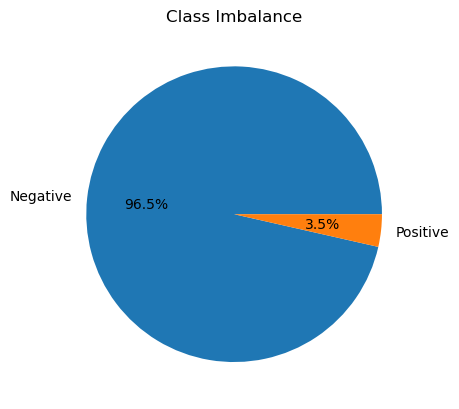

In [3]:
# get class imbalance
print(df['label'].value_counts())
num_neg = df['label'].value_counts()[0]
num_pos = df['label'].value_counts()[1]

plt.pie([num_neg, num_pos], labels=['Negative', 'Positive'], autopct='%1.1f%%')
plt.title('Class Imbalance')
plt.show()

# Dataset Loader

In [4]:
from tqdm.auto import tqdm

class ChestXRayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        self.images = []
        self.labels = []

        # Preload all images into memory to speed up training
        for idx in tqdm(range(len(self.df)), desc="Preloading images"):
            row = self.df.iloc[idx]
            img = io.BytesIO(row['image'])
            # The size of tensor a (9) must match the size of tensor b (3) at non-singleton dimension 0
            # channel dimension is 3, but the image is being read as 9 channels (probably due to the way the image is stored in the parquet file)
            img = Image.open(img).convert('RGB')  # Convert to RGB to ensure 3 channels

            self.images.append(img)
            self.labels.append(torch.tensor(int(row['label']), dtype=torch.float32))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Transforms for training and validation sets

In [5]:
IMG_SIZE = 224
train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ToTensor(),                        # converts to [0, 1]
    # transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # convert grayscale to 3 channels
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

val_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # convert grayscale to 3 channels
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Prepare training and validation sets

In [6]:
from sklearn.model_selection import train_test_split
X, y = df['image'], df['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
train_df = pd.DataFrame({'image': X_train, 'label': y_train}).reset_index(drop=True)
val_df   = pd.DataFrame({'image': X_val,   'label': y_val}).reset_index(drop=True)

# Prepare Data Loaders

In [7]:
train_dataset = ChestXRayDataset(train_df, transform=train_transforms)
val_dataset   = ChestXRayDataset(val_df, transform=val_transforms)

Preloading images: 100%|██████████| 1037/1037 [00:01<00:00, 923.20it/s]


In [8]:
# get class imbalance in training set
print(train_df['label'].value_counts())
num_neg = train_df['label'].value_counts()[0]
num_pos = train_df['label'].value_counts()[1]

label
0    4000
1     147
Name: count, dtype: int64


In [9]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    # num_workers=2,
    # pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    # num_workers=2,
    # pin_memory=True
)

# Model

In [18]:
# model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# for param in model.parameters():
    # param.requires_grad = False

# model.classifier = nn.Sequential(
#     nn.Linear(model.classifier.in_features, 128),
#     nn.ReLU(),
#     nn.Dropout(0.4),
#     nn.Linear(128, 1),
# )
# model.classifier = nn.Linear(model.classifier.in_features, 1)
model.fc = nn.Linear(model.fc.in_features, 1)

# Training Structure

In [19]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
model     = model.to(device)

pos_wt = np.float32(num_neg/num_pos)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_wt], device=device))

optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4, weight_decay=1e-4)
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("device:", device)

def train_epoch(model, loader, optimizer, criterion, pbar):
    model.train()
    total_loss, correct = 0, 0
    total_samples = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        pbar.set_postfix_str(f"(train) loss: {total_loss / total_samples:.4f} acc: {correct / total_samples:.4f}")
        pbar.update()
    return total_loss / len(loader), correct / len(loader.dataset)

def val_epoch(model, loader, criterion, pbar):
    model.eval()
    total_loss, correct = 0, 0
    total_samples = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            pbar.set_postfix_str(f"(val) loss: {total_loss / total_samples:.4f} acc: {correct / total_samples:.4f}")
            pbar.update()
    return total_loss / len(loader), correct / len(loader.dataset)

device: mps


# Train

In [20]:
from colorama import Fore

NUM_EPOCHS = 50

epochs = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1:02d}")
    with tqdm(total=len(train_loader)+len(val_loader), desc=f"Epoch {epoch+1:02d}") as pbar:
      train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, pbar)
      val_loss, val_acc     = val_epoch(model, val_loader, criterion, pbar)

      scheduler.step(val_loss)
      epochs.append((train_loss, train_acc, val_loss, val_acc))
      print(f"Train - {Fore.RED}Loss: {train_loss:.4f}{Fore.RESET} | {Fore.GREEN}Acc: {train_acc:.3f}{Fore.RESET}\n"
          f"Val   - {Fore.RED}Loss: {val_loss:.4f}{Fore.RESET} | {Fore.GREEN}Acc: {val_acc:.3f}{Fore.RESET}\n"
          f"LR: {optimizer.param_groups[0]['lr']:.1e}\n")

      if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# Restore best model
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model (val loss: {best_val_loss:.4f})")

Epoch 01


Epoch 01: 100%|██████████| 325/325 [00:46<00:00,  6.99it/s, (val) loss: 0.0122 acc: 0.9643]  


Train - Loss: 0.4510 | Acc: 0.874
Val   - Loss: 0.1950 | Acc: 0.964
LR: 1.0e-04

Epoch 02


Epoch 02: 100%|██████████| 325/325 [00:48<00:00,  6.69it/s, (val) loss: 0.0294 acc: 0.8862]  


Train - Loss: 0.2474 | Acc: 0.950
Val   - Loss: 0.4694 | Acc: 0.886
LR: 1.0e-04

Epoch 03


...

Train - Loss: 0.1945 | Acc: 0.956
Val   - Loss: 0.3697 | Acc: 0.888
LR: 1.0e-04

Epoch 04


Epoch 04: 100%|██████████| 325/325 [00:55<00:00,  5.90it/s, (val) loss: 0.0129 acc: 0.9817]  


Train - Loss: 0.2190 | Acc: 0.950
Val   - Loss: 0.2065 | Acc: 0.982
LR: 1.0e-04

Epoch 05


Epoch 05:  18%|█▊        | 58/325 [00:10<00:50,  5.32it/s, (train) loss: 0.0188 acc: 0.9688]


KeyboardInterrupt: 

# Plotting Accuracy/Loss

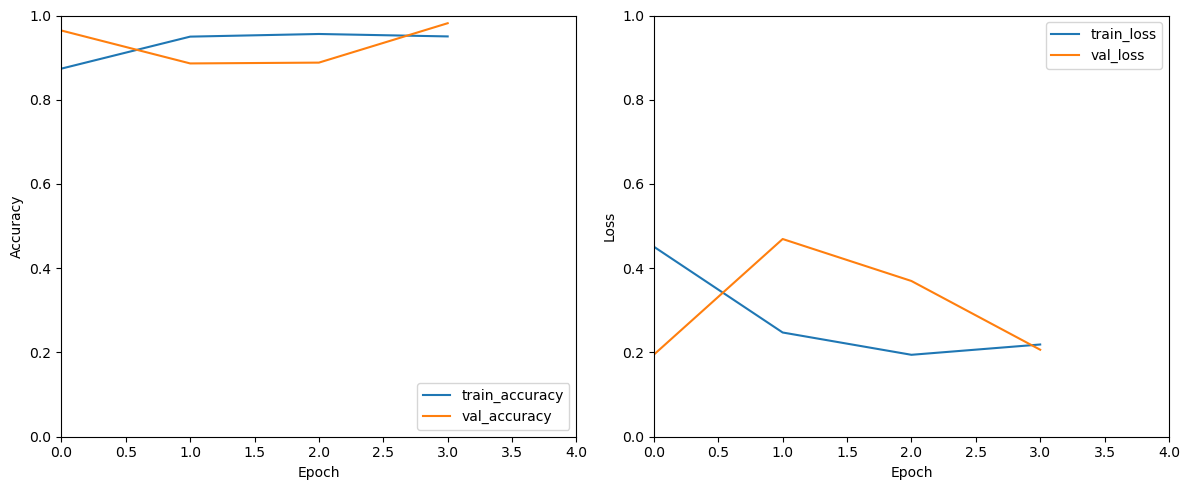

In [21]:
train_losses, train_accs, val_losses, val_accs = zip(*epochs)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(train_accs, label='train_accuracy')
axs[0].plot(val_accs, label='val_accuracy')
axs[0].set_ylim(0, 1)
axs[0].set_xlim(0, len(epochs))
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend(loc='lower right')

axs[1].plot(train_losses, label='train_loss')
axs[1].plot(val_losses, label='val_loss')
axs[1].set_ylim(0, 1)
axs[1].set_xlim(0, len(epochs))
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Evaluation Metrics

Classification Report on Test Set (Threshold: 0.5):
              precision    recall  f1-score   support

    Negative       1.00      0.93      0.96      1000
    Positive       0.32      0.89      0.47        37

    accuracy                           0.93      1037
   macro avg       0.66      0.91      0.72      1037
weighted avg       0.97      0.93      0.94      1037

AUC-ROC: 0.9658


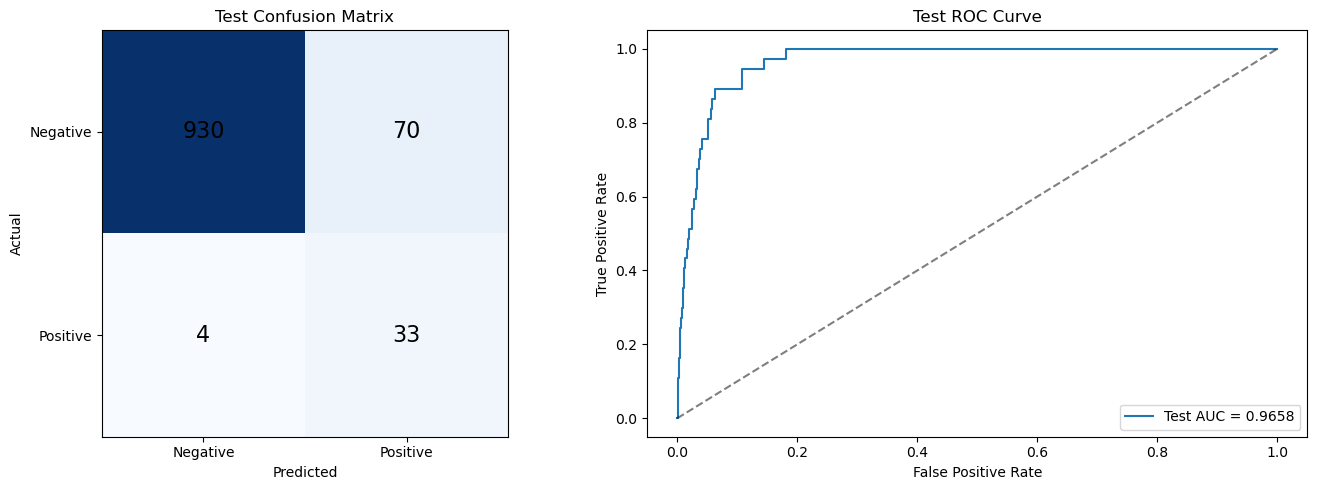

In [22]:
# Collect predictions on the TEST set
model.eval()
all_labels = []
all_probs = []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy().flatten())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

THRESHOLD = 0.5
all_preds = (all_probs > THRESHOLD).astype(int)

# Classification report (precision, recall, F1)
print(f"Classification Report on Test Set (Threshold: {THRESHOLD}):")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

# AUC-ROC
auc = roc_auc_score(all_labels, all_probs)
print(f"AUC-ROC: {auc:.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Test Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Negative', 'Positive'])
axes[0].set_yticklabels(['Negative', 'Positive'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16)

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f'Test AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Test ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()